# Smart Waste Image Classifier — Improved
CNN + MobileNetV2 with BatchNorm, Dropout, Fine-tuning, Callbacks

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)

2026-04-20 06:21:10.485076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776666070.682666      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776666070.739236      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776666071.179694      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666071.179734      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666071.179736      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 1. Import Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download('asdasdasasdas/garbage-classification')
print('Path to dataset files:', path)

Path to dataset files: /kaggle/input/datasets/asdasdasasdas/garbage-classification


## 2. Dataset Path & Config

In [3]:
DATASET_PATH = '/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification'

IMG_SIZE  = 224
BATCH_SIZE = 32
NUM_CLASSES = 6

## 3. Improved Data Augmentation

In [4]:
# ── Augmentation ─────────────────────────────────────────
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          
    zoom_range=0.3,             
    horizontal_flip=True,
    vertical_flip=True,         
    brightness_range=[0.8, 1.2],
    shear_range=0.2,            
    width_shift_range=0.1,      
    height_shift_range=0.1,     
    validation_split=0.2
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Class indices:', train_data.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Found 2527 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 4. Shared Callbacks

In [5]:
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/kaggle/working/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

## 5. Improved CNN Model
Added BatchNorm + Dropout after every Conv block, extra Conv block, larger Dense head.

In [6]:
def build_cnn(num_classes=6):
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4  
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)   
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


cnn_model = build_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

I0000 00:00:1776666099.847041      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,                      
    callbacks=get_callbacks('cnn')
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1776666166.663720     145 service.cc:152] XLA service 0x7a20c4116b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776666166.663756     145 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776666167.349035     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/64 ━━━━━━━━━━━━━━━━━━━━ 12:51 12s/step - accuracy: 0.0938 - loss: 2.2901

I0000 00:00:1776666175.203709     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.3406 - loss: 1.8119
Epoch 1: val_accuracy improved from -inf to 0.23459, saving model to /kaggle/working/cnn_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 760ms/step - accuracy: 0.3416 - loss: 1.8081 - val_accuracy: 0.2346 - val_loss: 2.3053 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5020 - loss: 1.2961
Epoch 2: val_accuracy improved from 0.23459 to 0.24056, saving model to /kaggle/working/cnn_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 538ms/step - accuracy: 0.5023 - loss: 1.2958 - val_accuracy: 0.2406 - val_loss: 2.1163 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5299 - loss: 1.2081
Epoch 3: val_accuracy did not improve from 0.24056
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 521ms/step - accuracy: 0.5300 - loss: 1.2080 - val_accuracy: 0.2346 - val_loss: 3.1136 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.5559 - 

## 6. MobileNetV2 with Fine-Tuning
Phase 1 — train head only.  Phase 2 — unfreeze last 30 layers with low LR.

In [12]:
# ── Phase 1: Frozen base ──────────────────────────────────────────────────────
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = tf.keras.Model(inputs, outputs)
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1 — training classification head only')
mobile_history_p1 = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=get_callbacks('mobilenet_phase1')
)

Phase 1 — training classification head only
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5319 - loss: 1.2644
Epoch 1: val_accuracy improved from -inf to 0.69980, saving model to /kaggle/working/mobilenet_phase1_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 678ms/step - accuracy: 0.5333 - loss: 1.2605 - val_accuracy: 0.6998 - val_loss: 0.7520 - learning_rate: 0.0010
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7417 - loss: 0.6843
Epoch 2: val_accuracy improved from 0.69980 to 0.70974, saving model to /kaggle/working/mobilenet_phase1_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 543ms/step - accuracy: 0.7418 - loss: 0.6843 - val_accuracy: 0.7097 - val_loss: 0.7637 - learning_rate: 0.0010
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7844 - loss: 0.5810
Epoch 3: val_accuracy did not improve from 0.70974
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 539ms/step - accuracy: 0.7844 - loss: 0.5808 - val_accuracy: 0.6978 - val_loss: 0.7418 - learning_rate:

In [13]:
# ── Phase 2: Unfreeze last 30 layers, low LR ─────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2 — fine-tuning last 30 MobileNetV2 layers')
mobile_history_p2 = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,                      
    callbacks=get_callbacks('mobilenet_phase2')
)

Phase 2 — fine-tuning last 30 MobileNetV2 layers
Epoch 1/20


2026-04-20 06:51:55.293880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 06:51:55.490430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6733 - loss: 0.9971
Epoch 1: val_accuracy improved from -inf to 0.72763, saving model to /kaggle/working/mobilenet_phase2_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 767ms/step - accuracy: 0.6739 - loss: 0.9951 - val_accuracy: 0.7276 - val_loss: 0.7322 - learning_rate: 1.0000e-05
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7690 - loss: 0.6636
Epoch 2: val_accuracy did not improve from 0.72763
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 509ms/step - accuracy: 0.7691 - loss: 0.6628 - val_accuracy: 0.7117 - val_loss: 0.7926 - learning_rate: 1.0000e-05
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7917 - loss: 0.5567
Epoch 3: val_accuracy did not improve from 0.72763
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 508ms/step - accuracy: 0.7918 - loss: 0.5565 - val_accuracy: 0.7197 - val_loss: 0.7987 - learning_rate: 1.0000e-05
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8299 - loss: 0.5050
Epoch 4: Reduc

## 7. Evaluation

In [14]:
class_names = list(train_data.class_indices.keys())

for name, model in [('CNN', cnn_model), ('MobileNetV2', mobilenet_model)]:
    y_true = test_data.classes
    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    print(f'\n=== {name} ===' )
    print(classification_report(y_true, y_pred, target_names=class_names))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))


=== CNN ===
              precision    recall  f1-score   support

   cardboard       0.95      0.87      0.91       403
       glass       0.69      0.68      0.68       501
       metal       0.70      0.55      0.62       410
       paper       0.74      0.92      0.82       594
     plastic       0.62      0.72      0.67       482
       trash       0.76      0.20      0.32       137

    accuracy                           0.73      2527
   macro avg       0.74      0.66      0.67      2527
weighted avg       0.74      0.73      0.72      2527

Confusion Matrix:
[[352   1   6  23  21   0]
 [  0 339  53  24  85   0]
 [  2  49 227  38  91   3]
 [  5  17   9 548  12   3]
 [  6  37  11  76 349   3]
 [  6  50  16  34   3  28]]

=== MobileNetV2 ===
              precision    recall  f1-score   support

   cardboard       0.98      0.89      0.93       403
       glass       0.90      0.84      0.87       501
       metal       0.93      0.90      0.91       410
       paper       0.88  

## 8. Training Curves

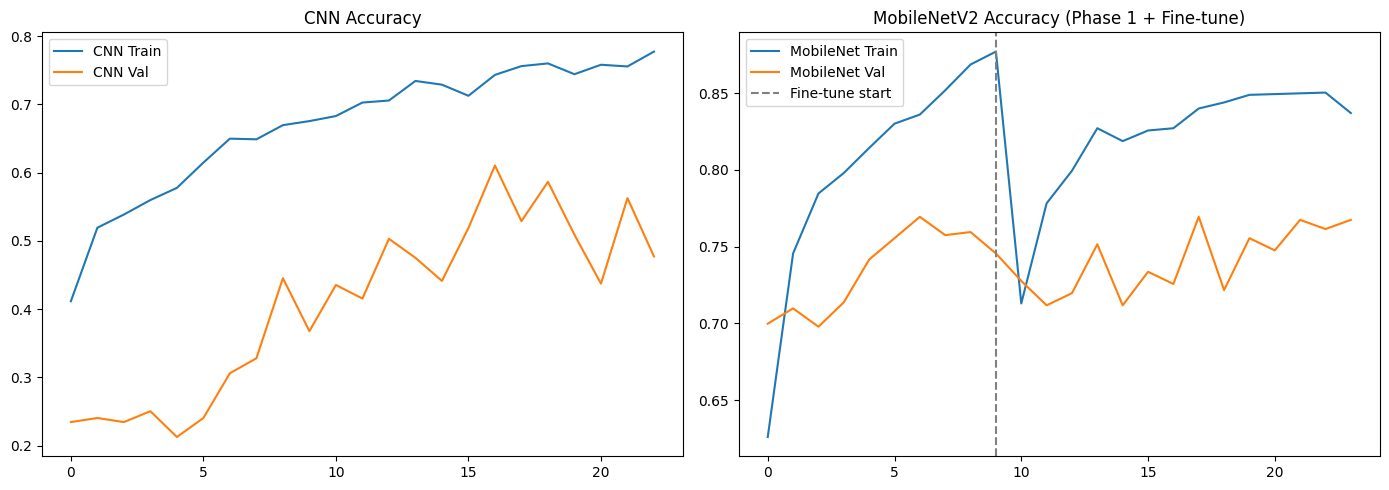

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CNN
axes[0].plot(cnn_history.history['accuracy'],     label='CNN Train')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val')
axes[0].set_title('CNN Accuracy')
axes[0].legend()

# MobileNet (combine phase 1 + 2)
mob_train = mobile_history_p1.history['accuracy']     + mobile_history_p2.history['accuracy']
mob_val   = mobile_history_p1.history['val_accuracy'] + mobile_history_p2.history['val_accuracy']
axes[1].plot(mob_train, label='MobileNet Train')
axes[1].plot(mob_val,   label='MobileNet Val')
axes[1].axvline(len(mobile_history_p1.history['accuracy']) - 1,
                color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('MobileNetV2 Accuracy (Phase 1 + Fine-tune)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Save Models

In [16]:
cnn_model.save('/kaggle/working/cnn_model.h5')
mobilenet_model.save('/kaggle/working/mobilenet_model.h5')
print('Models saved.')

Models saved.
